# Employee Performance Analysis

## Exploratory Data Analysis

### Project Objective

The objective of this exploratory analysis is to understand the distribution of employee performance and identify relationships between employee characteristics, workplace factors, and `PerformanceRating`.

The analysis focuses on:

- Understanding the distribution of employee performance ratings
- Examining department-wise performance
- Studying relationships between categorical, ordinal, and numerical variables and employee performance
- Identifying patterns and potential factors associated with employee performance
- Generating business insights that can support the objectives of INX Future Inc.

The exploratory findings will be used to guide the subsequent machine learning model development and business recommendations.

### 1.1 Load the Processed Dataset

The processed employee performance dataset generated during data processing is loaded for exploratory analysis.

The dataset used here excludes the employee identifier from the modeling dataset and retains `PerformanceRating` as the target variable.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Path to processed dataset
processed_path = "../../data/processed/employee_performance_processed.csv"

# Load processed dataset
df = pd.read_csv(processed_path)

print("Processed dataset loaded successfully.")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Processed dataset loaded successfully.
Rows    : 1200
Columns : 27


### 1.2 Dataset Overview

A basic overview of the processed dataset is performed before detailed exploratory analysis.

The dimensions, data types, missing values, and initial records are examined to confirm that the expected processed dataset has been loaded.

In [2]:
print("Dataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nData types:")
display(df.dtypes.to_frame(name="Data Type"))

print("\nFirst five records:")
display(df.head())

Dataset shape:
(1200, 27)

Missing values:
0

Data types:


,Data Type
Age,int64
Gender,str
EducationBackground,str
MaritalStatus,str
EmpDepartment,str
EmpJobRole,str
BusinessTravelFrequency,str
DistanceFromHome,int64
EmpEducationLevel,int64
EmpEnvironmentSatisfaction,int64



First five records:


,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3
2,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,Yes,21,3,20,2,3,18,13,1,12,No,4
3,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,No,15,2,23,2,2,21,6,12,6,No,3
4,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,No,14,4,10,1,3,2,2,2,2,No,3


### 1.3 Target Variable: Performance Rating

`PerformanceRating` is the target variable for the employee performance analysis.

The distribution of performance ratings is examined to understand how employees are distributed across the observed performance categories.

The analysis also checks whether the target classes are balanced, as class imbalance can affect the evaluation and interpretation of classification models.

In [3]:
# Performance rating distribution
performance_counts = (
    df["PerformanceRating"]
    .value_counts()
    .sort_index()
)

performance_percentage = (
    df["PerformanceRating"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

performance_distribution = pd.DataFrame({
    "Count": performance_counts,
    "Percentage": performance_percentage.round(2)
})

display(performance_distribution)

,Count,Percentage
PerformanceRating,,
2,194,16.17
3,874,72.83
4,132,11.00


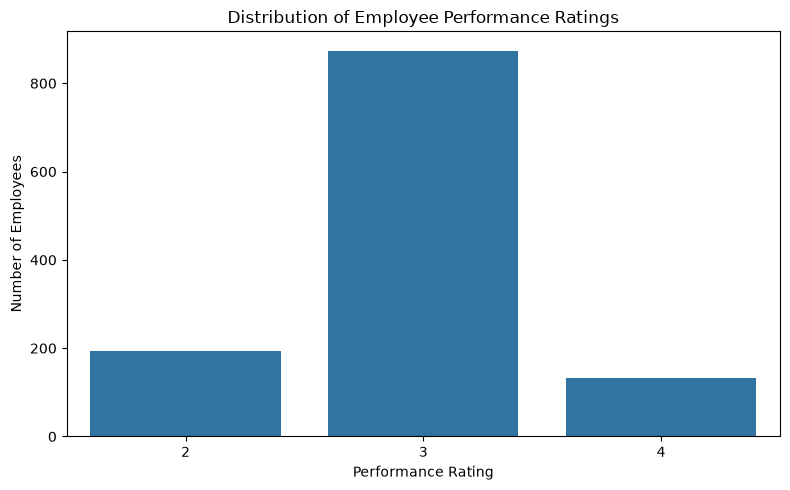

In [4]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="PerformanceRating",
    order=sorted(df["PerformanceRating"].unique())
)

plt.title("Distribution of Employee Performance Ratings")
plt.xlabel("Performance Rating")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

In [5]:
# Print the distribution in a readable form
for rating, row in performance_distribution.iterrows():
    print(
        f"Performance Rating {rating}: "
        f"{int(row['Count'])} employees "
        f"({row['Percentage']:.2f}%)"
    )

Performance Rating 2: 194 employees (16.17%)
Performance Rating 3: 874 employees (72.83%)
Performance Rating 4: 132 employees (11.00%)


### 1.4 Univariate Analysis: Categorical Variables

The categorical variables are analyzed individually to understand the composition of the employee dataset.

Frequency distributions are examined for each categorical variable before investigating their relationship with employee performance.

This analysis helps identify the most common employee characteristics and organizational categories represented in the dataset.

In [6]:
# Categorical variables in the processed dataset
categorical_columns = [
    "Gender",
    "EducationBackground",
    "MaritalStatus",
    "EmpDepartment",
    "EmpJobRole",
    "BusinessTravelFrequency",
    "OverTime",
    "Attrition"
]

print("Categorical variables:")
for column in categorical_columns:
    print("-", column)

Categorical variables:
- Gender
- EducationBackground
- MaritalStatus
- EmpDepartment
- EmpJobRole
- BusinessTravelFrequency
- OverTime
- Attrition


In [7]:
for column in categorical_columns:
    print("=" * 70)
    print(column)
    print("=" * 70)
    
    frequency_table = (
        df[column]
        .value_counts()
        .rename_axis(column)
        .reset_index(name="Count")
    )
    
    frequency_table["Percentage"] = (
        frequency_table["Count"] / len(df) * 100
    ).round(2)
    
    display(frequency_table)

Gender


,Gender,Count,Percentage
0,Male,725,60.42
1,Female,475,39.58


EducationBackground


,EducationBackground,Count,Percentage
0,Life Sciences,492,41.00
1,Medical,384,32.00
2,Marketing,137,11.42
3,Technical Degree,100,8.33
4,Other,66,5.50
5,Human Resources,21,1.75


MaritalStatus


...

,BusinessTravelFrequency,Count,Percentage
0,Travel_Rarely,846,70.5
1,Travel_Frequently,222,18.5
2,Non-Travel,132,11.0


OverTime


,OverTime,Count,Percentage
0,No,847,70.58
1,Yes,353,29.42


Attrition


,Attrition,Count,Percentage
0,No,1022,85.17
1,Yes,178,14.83


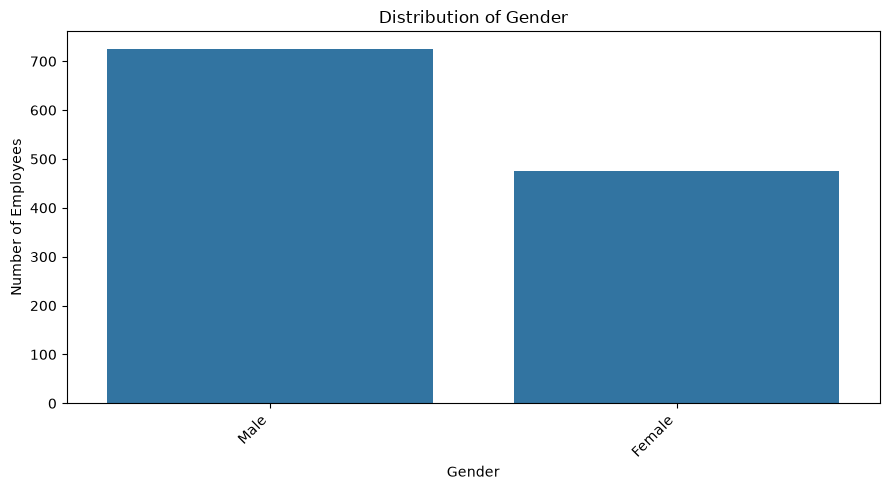

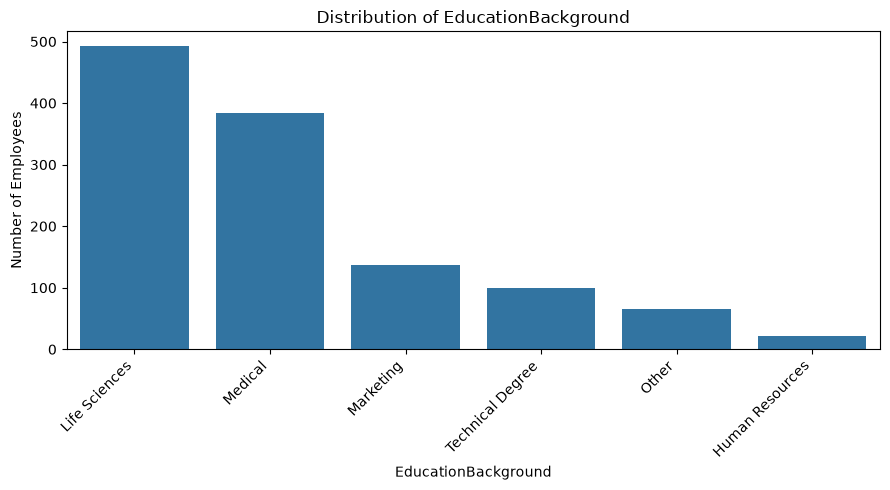

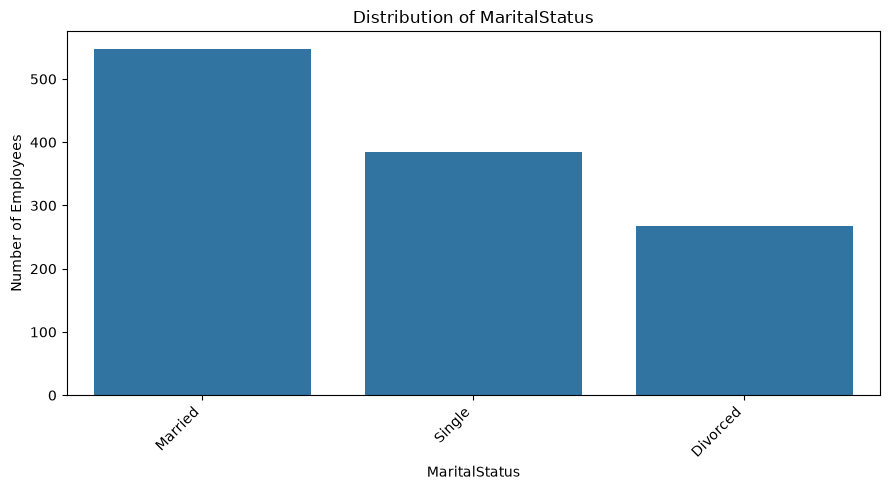

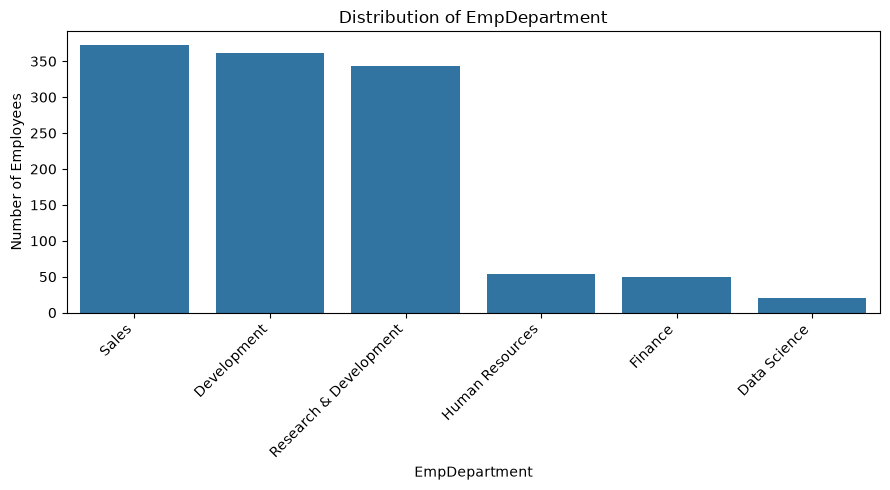

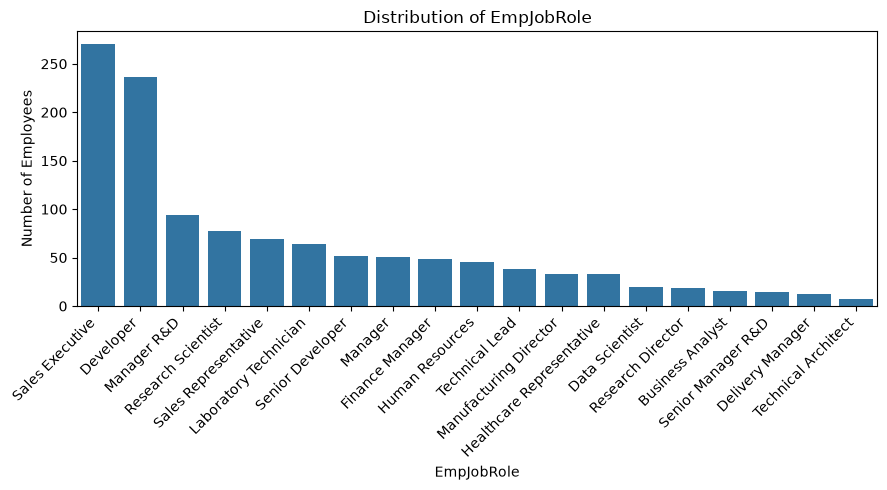

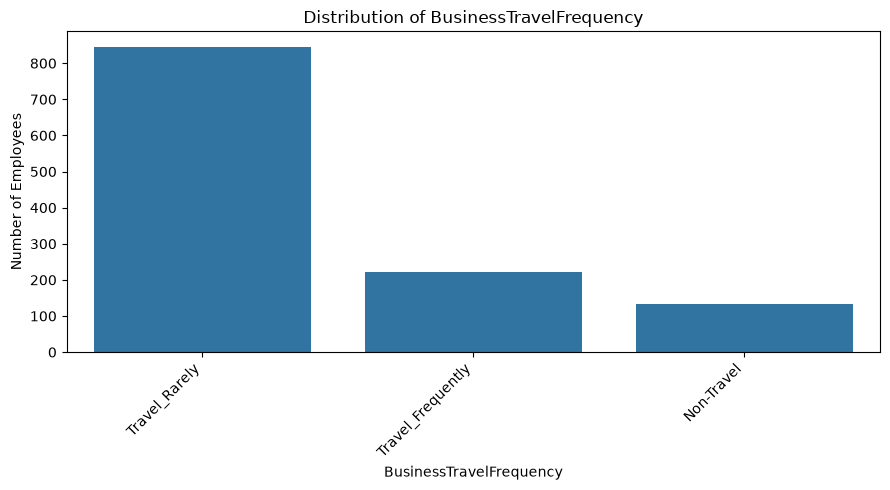

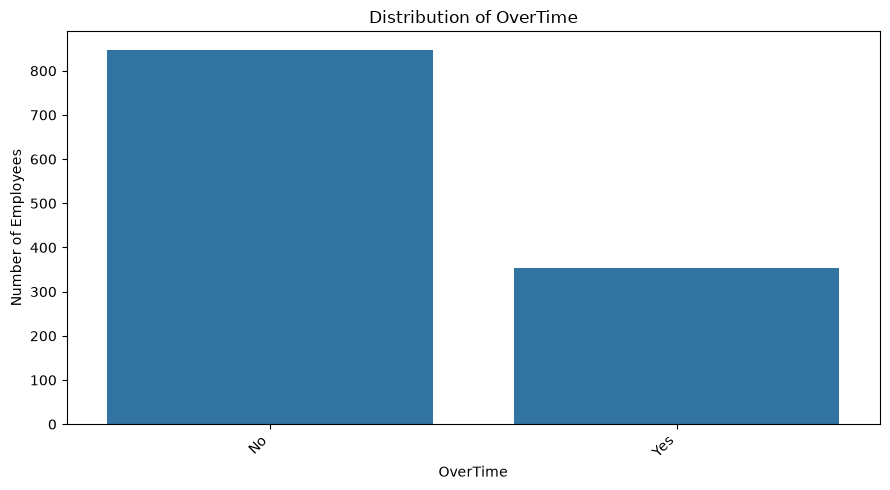

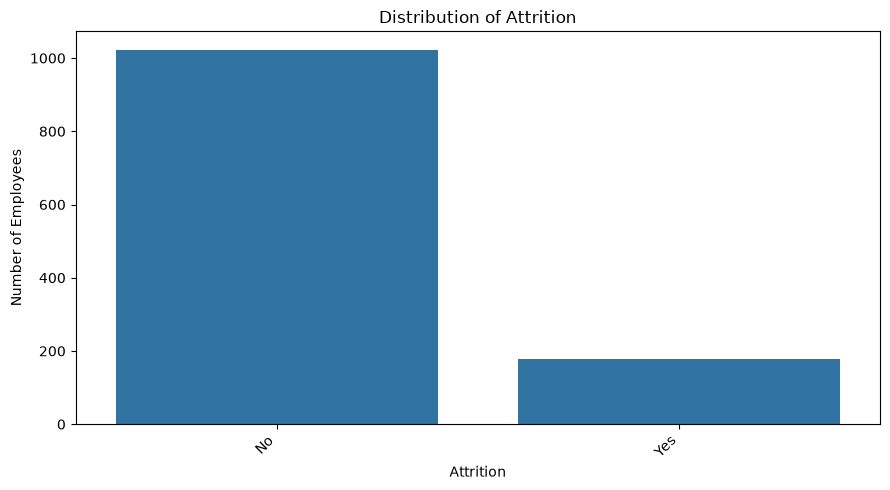

In [8]:
for column in categorical_columns:
    
    plt.figure(figsize=(9, 5))
    
    order = df[column].value_counts().index
    
    sns.countplot(
        data=df,
        x=column,
        order=order
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Employees")
    plt.xticks(rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()

### 1.5 Categorical Variables vs Performance Rating

The relationship between categorical employee characteristics and `PerformanceRating` is examined to identify differences in performance-rating distributions across employee groups.

Because the categorical groups contain different numbers of employees, percentage-based comparisons are used alongside employee counts.

The analysis identifies associations and patterns that can be investigated further during statistical analysis and machine learning. These relationships should not be interpreted as evidence of causation.

In [9]:
department_performance = pd.crosstab(
    df["EmpDepartment"],
    df["PerformanceRating"]
)

display(department_performance)

PerformanceRating,2,3,4
EmpDepartment,,,
Data Science,1,17,2
Development,13,304,44
Finance,15,30,4
Human Resources,10,38,6
Research & Development,68,234,41
Sales,87,251,35


In [10]:
department_performance_pct = pd.crosstab(
    df["EmpDepartment"],
    df["PerformanceRating"],
    normalize="index"
).mul(100).round(2)

display(department_performance_pct)

PerformanceRating,2,3,4
EmpDepartment,,,
Data Science,5.00,85.00,10.00
Development,3.60,84.21,12.19
Finance,30.61,61.22,8.16
Human Resources,18.52,70.37,11.11
Research & Development,19.83,68.22,11.95
Sales,23.32,67.29,9.38


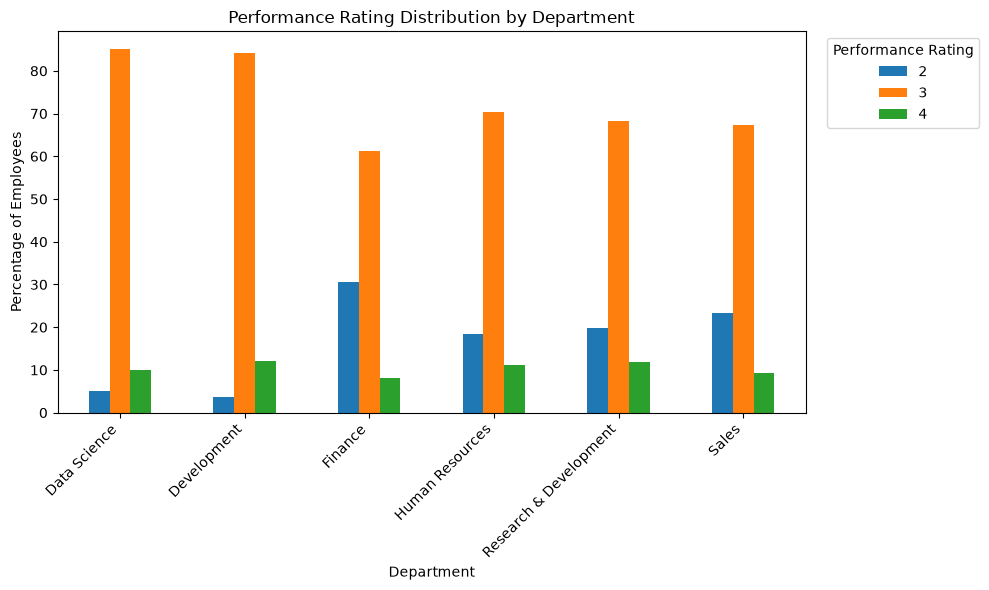

In [11]:
department_performance_pct.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Rating Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Percentage of Employees")
plt.xticks(rotation=45, ha="right")
plt.legend(
    title="Performance Rating",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### 1.5.1 Other Categorical Variables vs Performance Rating

The remaining categorical variables are compared with `PerformanceRating` to identify differences in performance-rating distributions across employee groups.

Within-category percentages are used because the number of employees varies across categories.

The results are interpreted as associations and descriptive patterns rather than causal effects.

In [12]:
categorical_analysis_columns = [
    "Gender",
    "EducationBackground",
    "MaritalStatus",
    "EmpJobRole",
    "BusinessTravelFrequency",
    "OverTime",
    "Attrition"
]

for column in categorical_analysis_columns:
    
    print("=" * 80)
    print(f"{column} vs PerformanceRating")
    print("=" * 80)
    
    # Employee counts by category and performance rating
    count_table = pd.crosstab(
        df[column],
        df["PerformanceRating"]
    )
    
    print("\nCount:")
    display(count_table)
    
    # Percentage within each category
    percentage_table = pd.crosstab(
        df[column],
        df["PerformanceRating"],
        normalize="index"
    ).mul(100).round(2)
    
    print("\nPercentage within category:")
    display(percentage_table)

Gender vs PerformanceRating

Count:


PerformanceRating,2,3,4
Gender,,,
Female,75,349,51
Male,119,525,81



Percentage within category:


PerformanceRating,2,3,4
Gender,,,
Female,15.79,73.47,10.74
Male,16.41,72.41,11.17


EducationBackground vs PerformanceRating

Count:


...

PerformanceRating,2,3,4
OverTime,,,
No,18.30,70.25,11.45
Yes,11.05,79.04,9.92


Attrition vs PerformanceRating

Count:


PerformanceRating,2,3,4
Attrition,,,
No,158,750,114
Yes,36,124,18



Percentage within category:


PerformanceRating,2,3,4
Attrition,,,
No,15.46,73.39,11.15
Yes,20.22,69.66,10.11


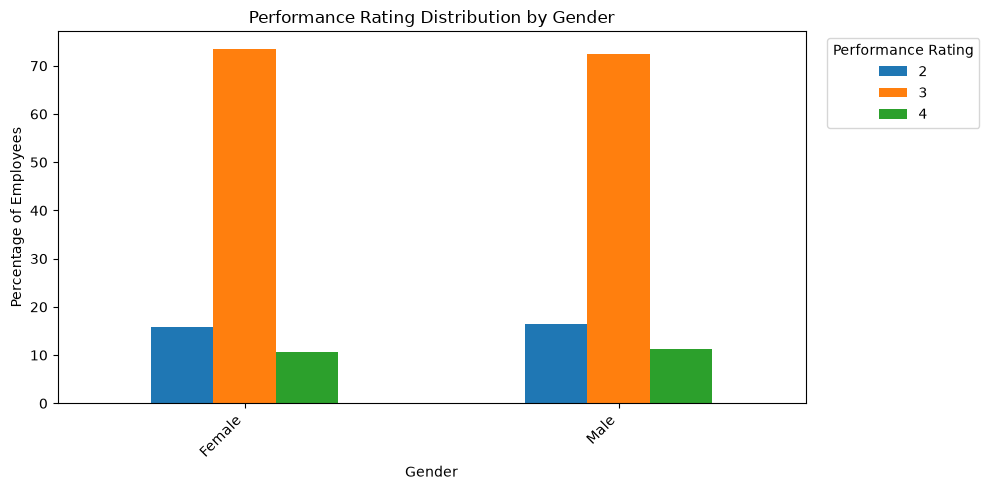

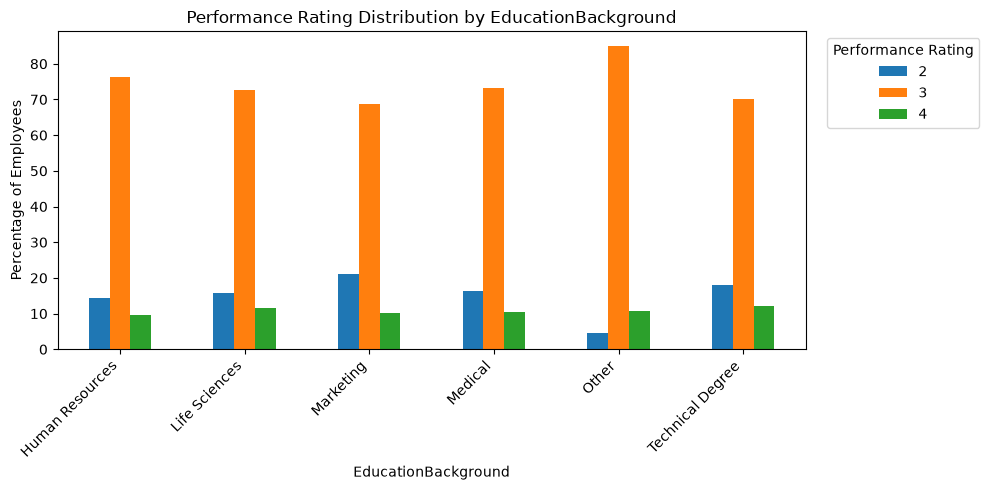

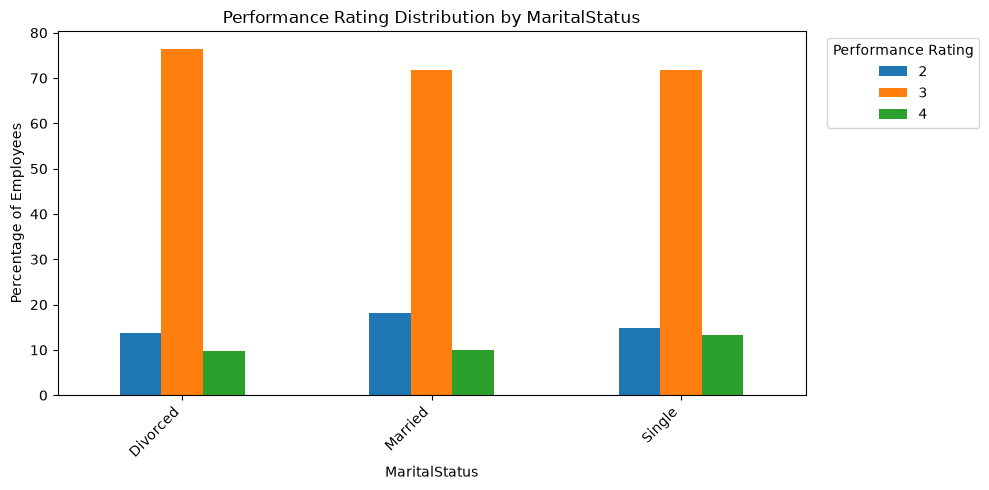

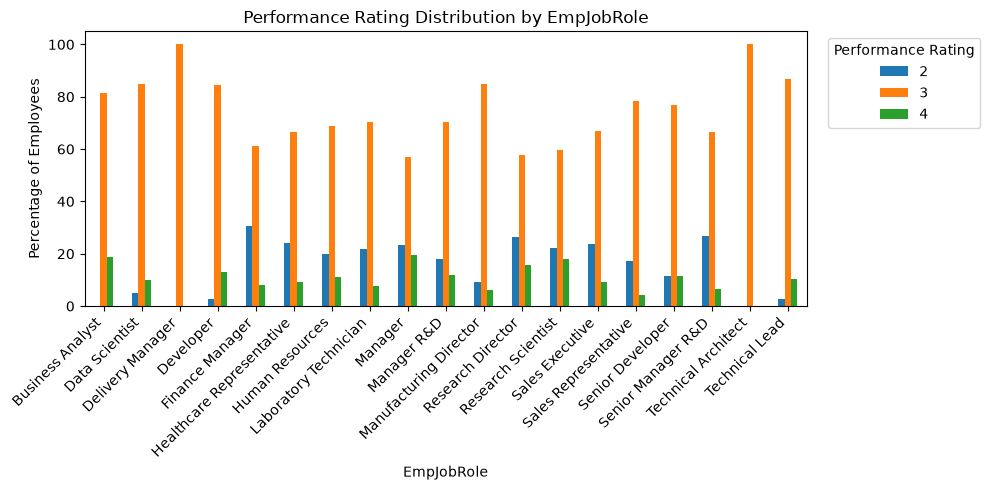

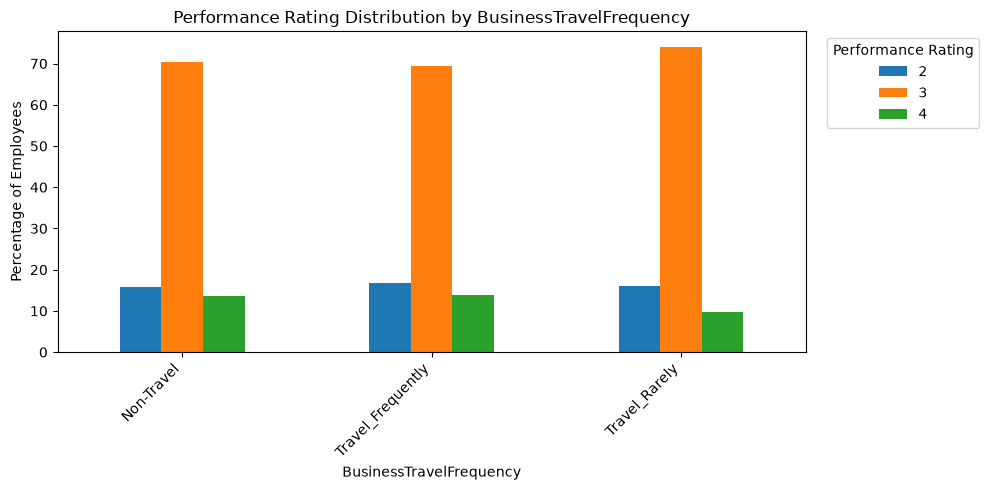

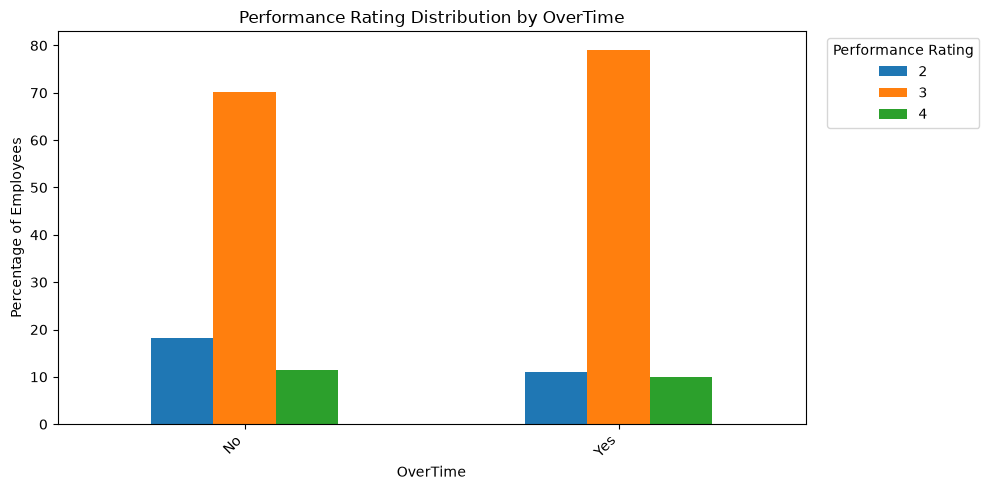

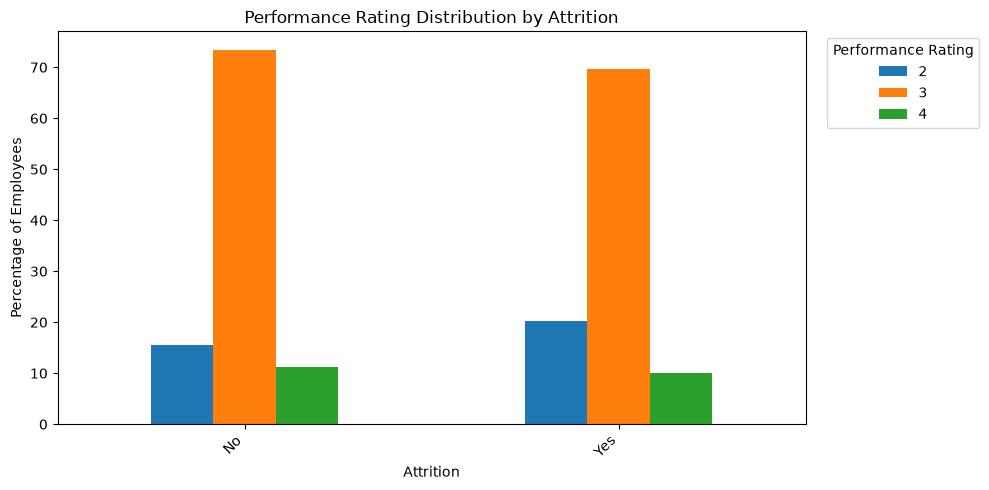

In [13]:
for column in categorical_analysis_columns:
    
    percentage_table = pd.crosstab(
        df[column],
        df["PerformanceRating"],
        normalize="index"
    ).mul(100)
    
    percentage_table.plot(
        kind="bar",
        figsize=(10, 5)
    )
    
    plt.title(f"Performance Rating Distribution by {column}")
    plt.xlabel(column)
    plt.ylabel("Percentage of Employees")
    plt.xticks(rotation=45, ha="right")
    plt.legend(
        title="Performance Rating",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    
    plt.tight_layout()
    plt.show()

### 1.6 Univariate Analysis: Numerical Variables

The numerical variables are examined individually to understand their distributions, ranges, central tendency, and variability.

Histograms and boxplots are used to identify the general distribution of each variable and potential extreme observations.

Potential outliers identified during exploratory analysis are not automatically removed because an extreme value may represent a genuine employee characteristic./


In [14]:
numerical_columns = [
    "Age",
    "DistanceFromHome",
    "EmpHourlyRate",
    "EmpJobLevel",
    "NumCompaniesWorked",
    "EmpLastSalaryHikePercent",
    "TotalWorkExperienceInYears",
    "TrainingTimesLastYear",
    "ExperienceYearsAtThisCompany",
    "ExperienceYearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

print("Numerical variables:")
for column in numerical_columns:
    print("-", column)

Numerical variables:
- Age
- DistanceFromHome
- EmpHourlyRate
- EmpJobLevel
- NumCompaniesWorked
- EmpLastSalaryHikePercent
- TotalWorkExperienceInYears
- TrainingTimesLastYear
- ExperienceYearsAtThisCompany
- ExperienceYearsInCurrentRole
- YearsSinceLastPromotion
- YearsWithCurrManager


In [15]:
numerical_summary = df[numerical_columns].describe().T

numerical_summary = numerical_summary[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
].round(2)

display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max
Age,1200.0,36.92,9.09,18.0,30.0,36.0,43.0,60.0
DistanceFromHome,1200.0,9.17,8.18,1.0,2.0,7.0,14.0,29.0
EmpHourlyRate,1200.0,65.98,20.21,30.0,48.0,66.0,83.0,100.0
EmpJobLevel,1200.0,2.07,1.11,1.0,1.0,2.0,3.0,5.0
NumCompaniesWorked,1200.0,2.66,2.47,0.0,1.0,2.0,4.0,9.0
EmpLastSalaryHikePercent,1200.0,15.22,3.63,11.0,12.0,14.0,18.0,25.0
TotalWorkExperienceInYears,1200.0,11.33,7.80,0.0,6.0,10.0,15.0,40.0
TrainingTimesLastYear,1200.0,2.79,1.26,0.0,2.0,3.0,3.0,6.0
ExperienceYearsAtThisCompany,1200.0,7.08,6.24,0.0,3.0,5.0,10.0,40.0
ExperienceYearsInCurrentRole,1200.0,4.29,3.61,0.0,2.0,3.0,7.0,18.0


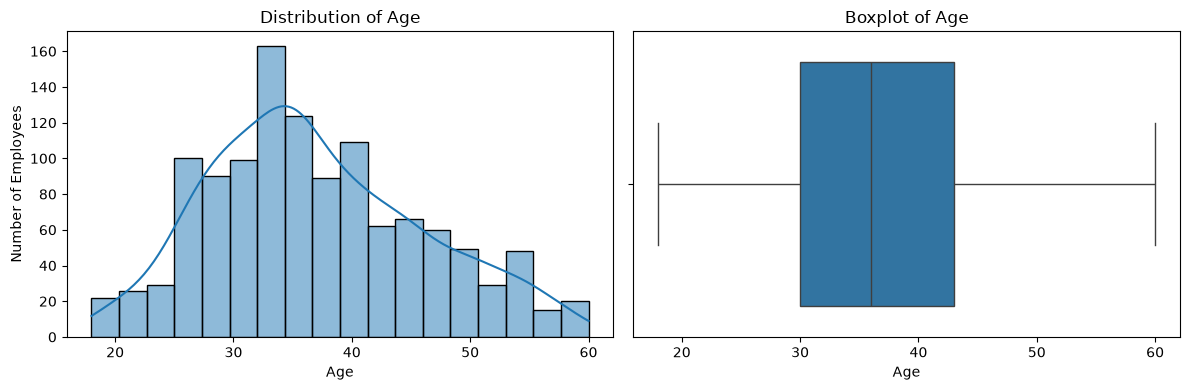

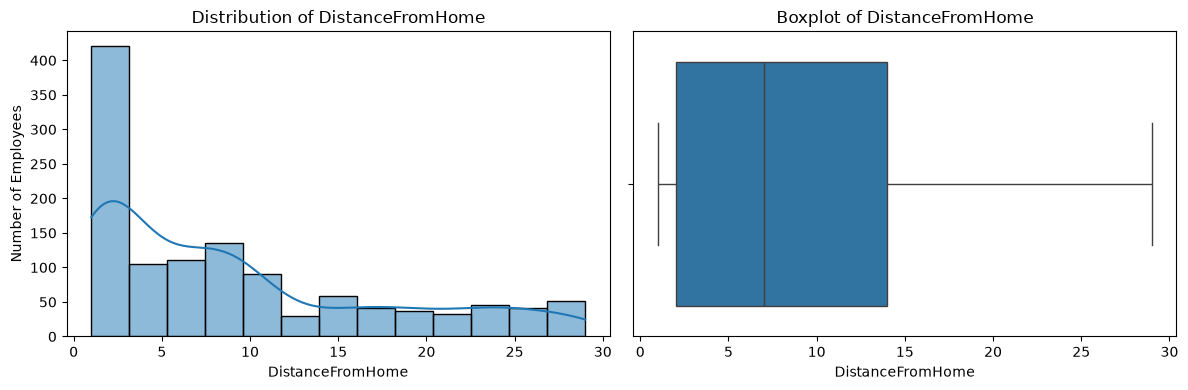

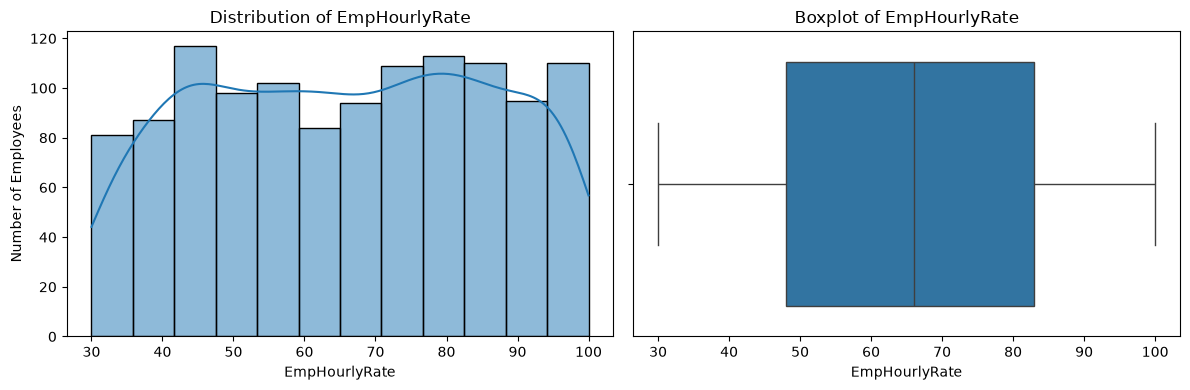

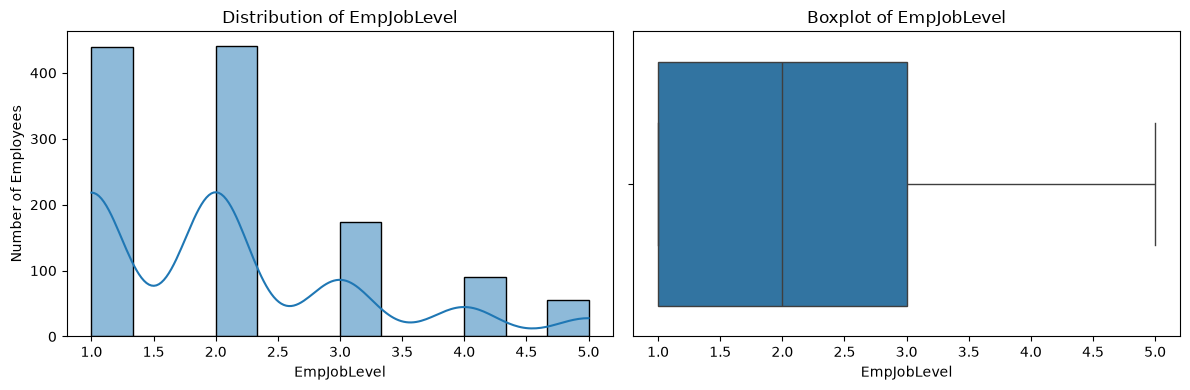

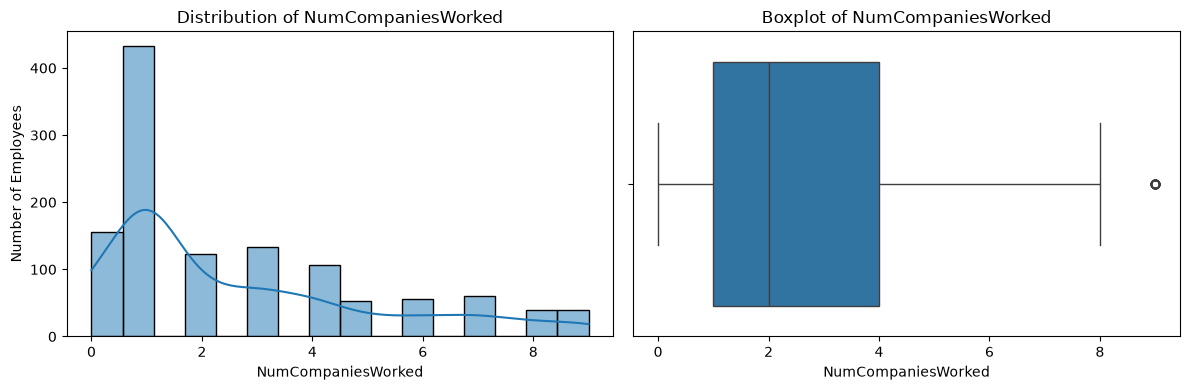

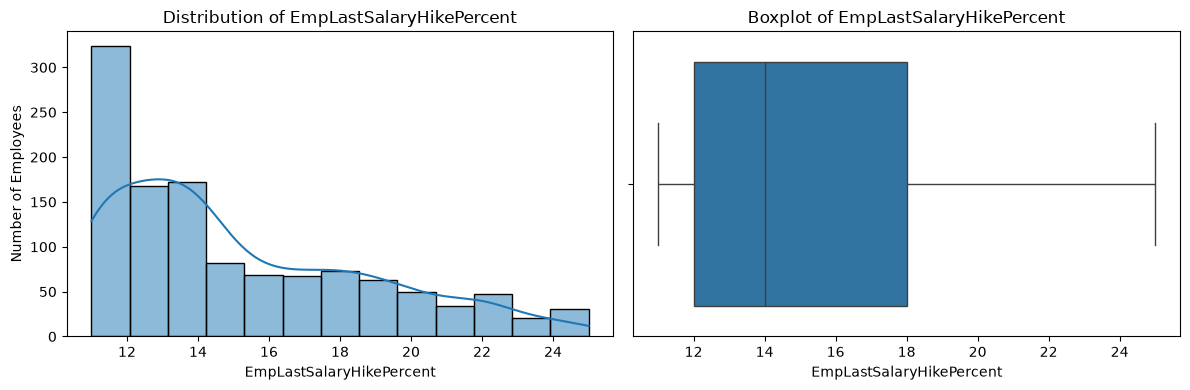

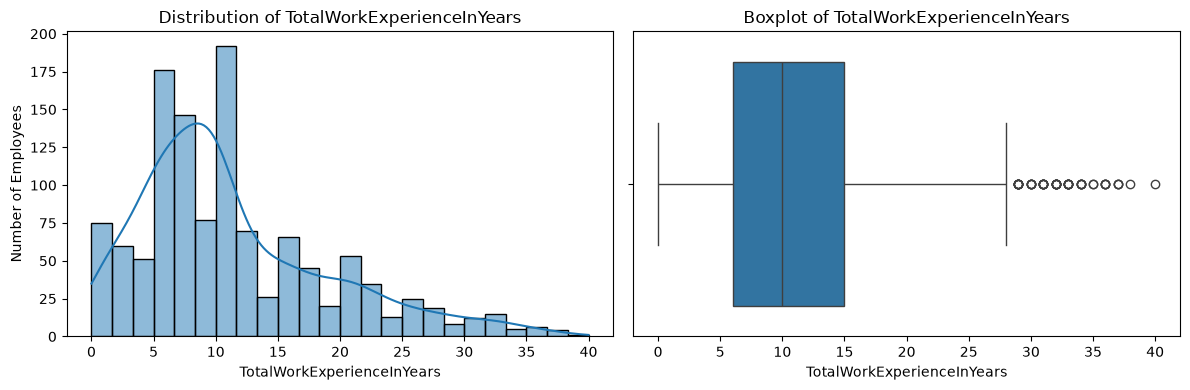

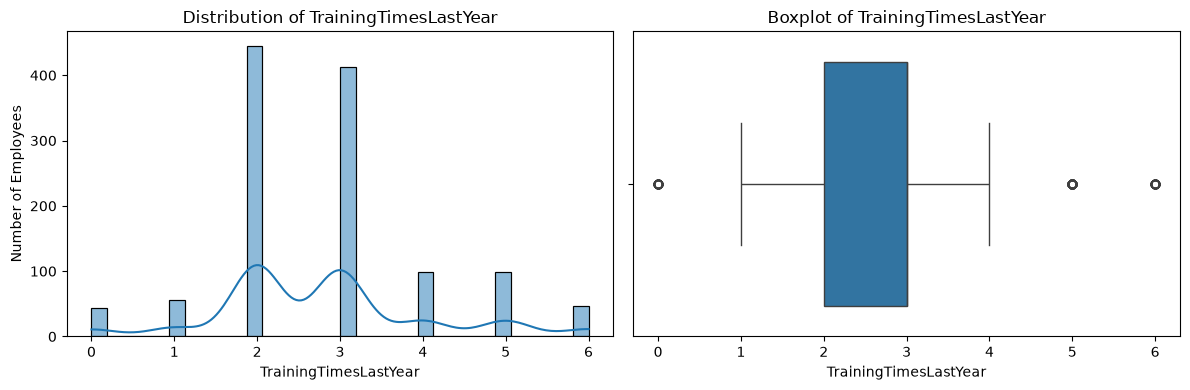

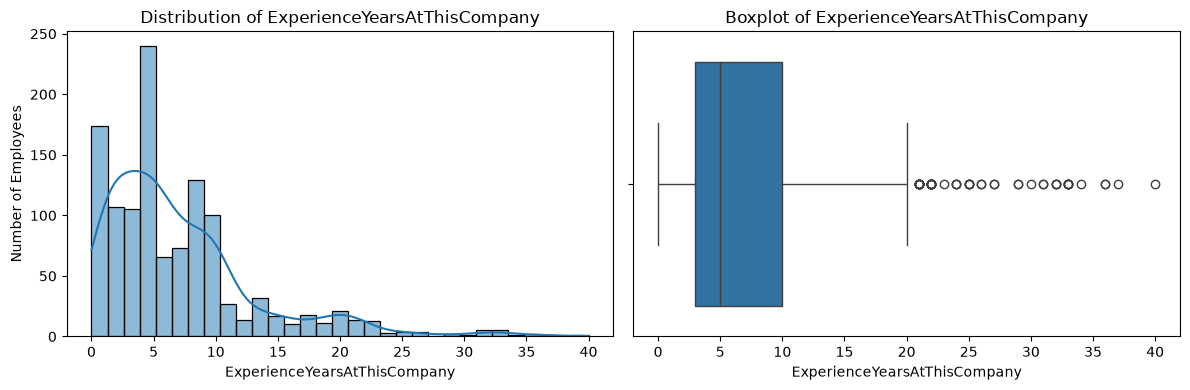

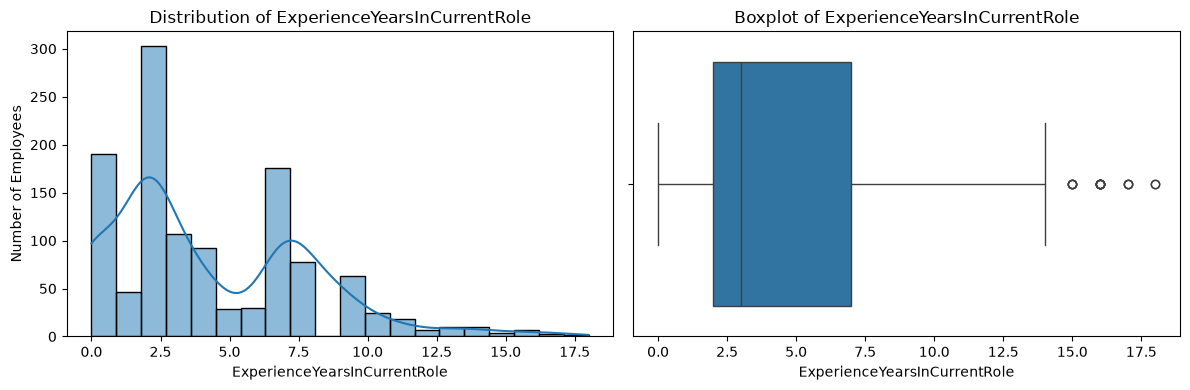

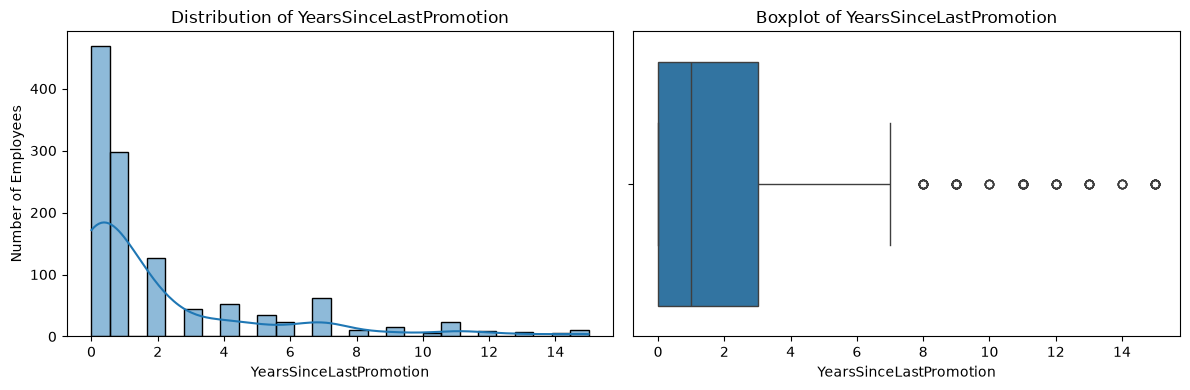

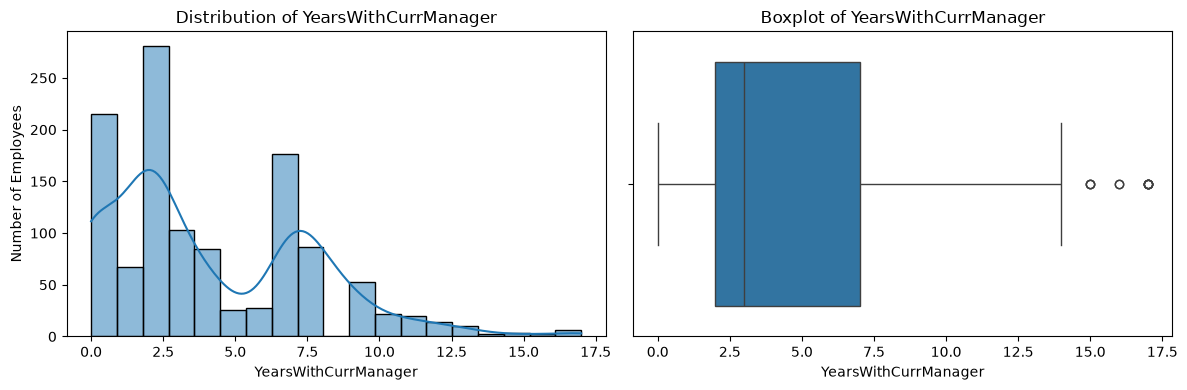

In [16]:
for column in numerical_columns:
    
    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 4)
    )
    
    # Histogram
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        ax=axes[0]
    )
    
    axes[0].set_title(f"Distribution of {column}")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Number of Employees")
    
    # Boxplot
    sns.boxplot(
        data=df,
        x=column,
        ax=axes[1]
    )
    
    axes[1].set_title(f"Boxplot of {column}")
    axes[1].set_xlabel(column)
    
    plt.tight_layout()
    plt.show()

### 1.7 Numerical Variables vs Performance Rating

The numerical variables are compared across employee performance-rating classes to identify differences in their distributions.

Boxplots are used to compare the central tendency, spread, and potential extreme observations of each numerical variable across `PerformanceRating` groups.

These comparisons are used to identify variables that may have useful predictive relationships with employee performance. The observed patterns represent associations and should not be interpreted as causal effects.

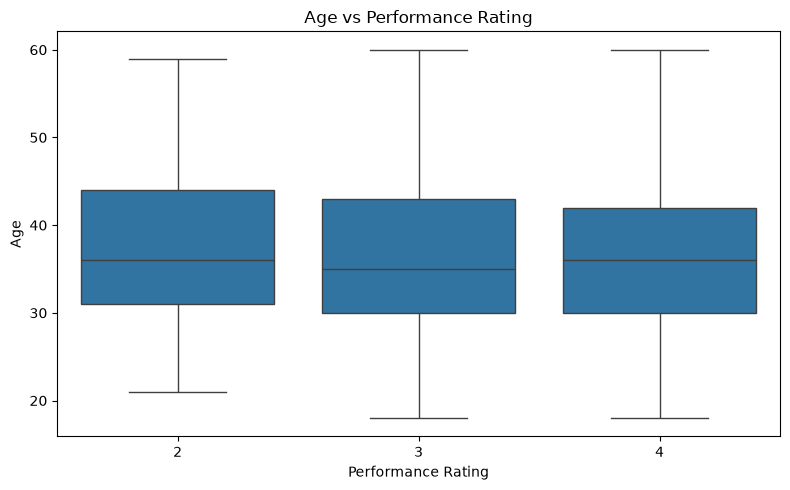

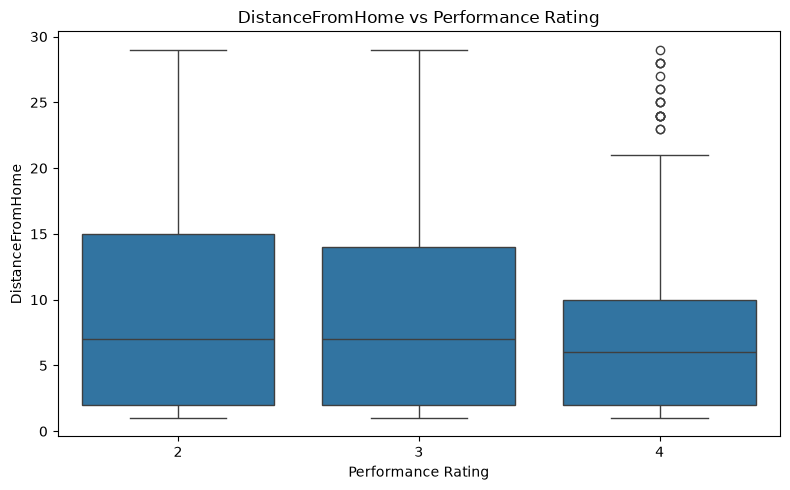

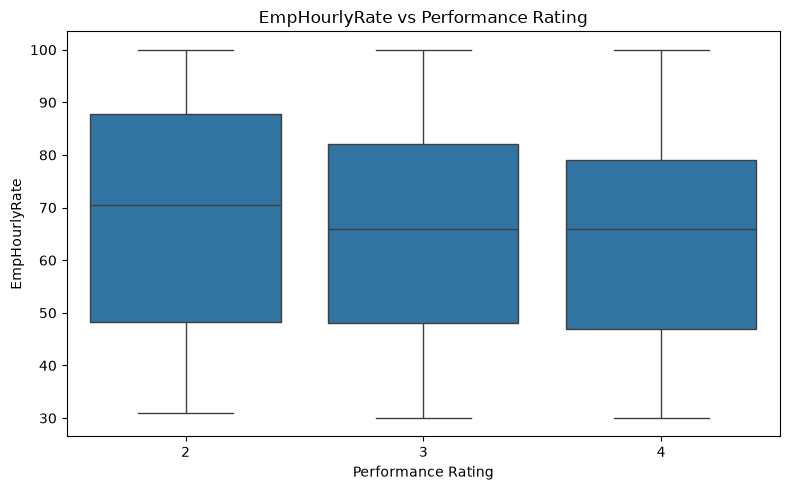

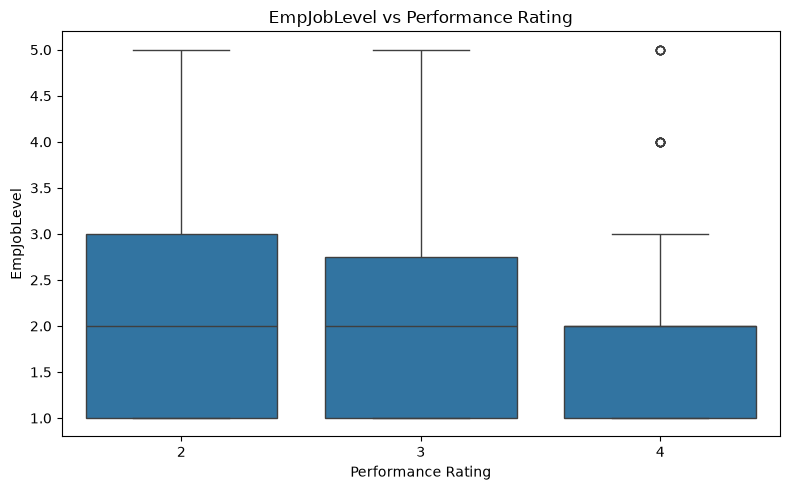

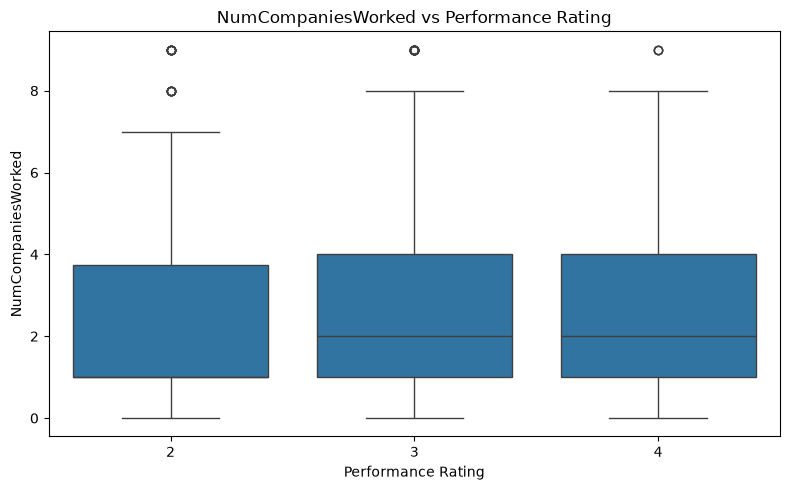

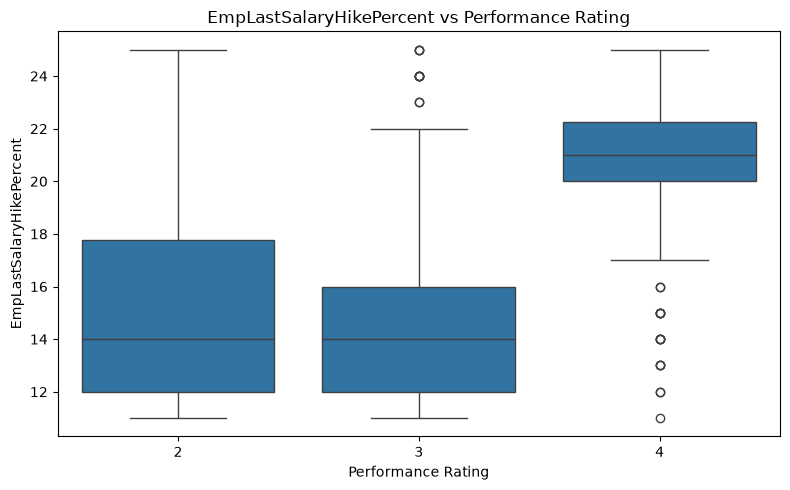

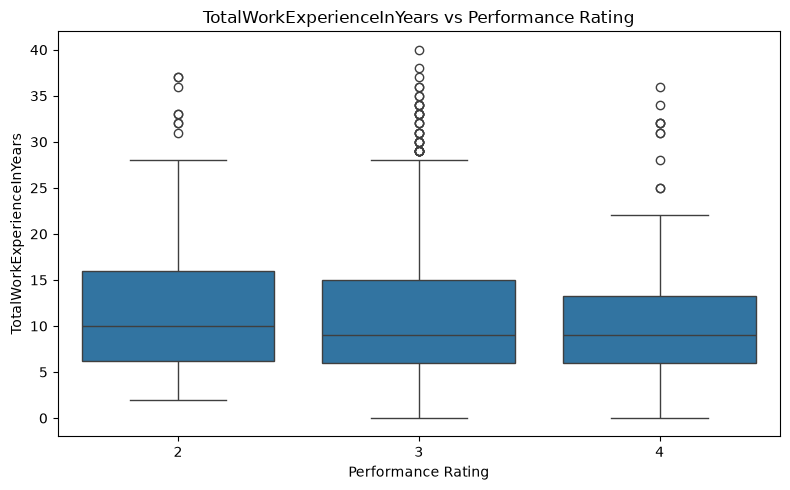

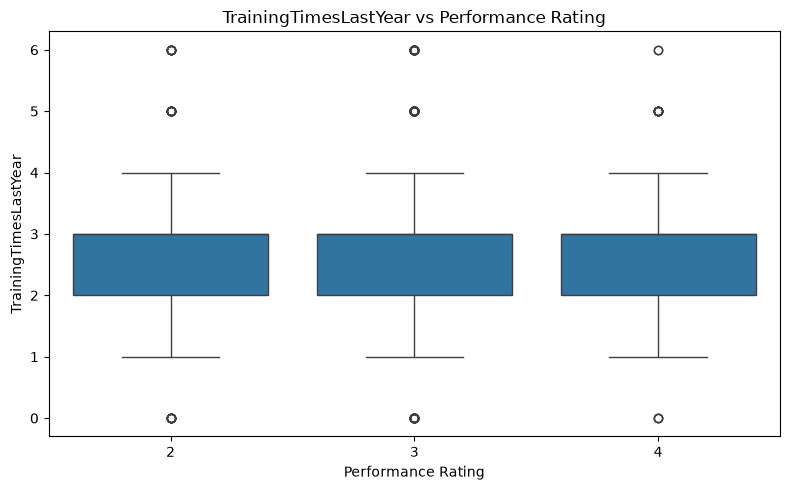

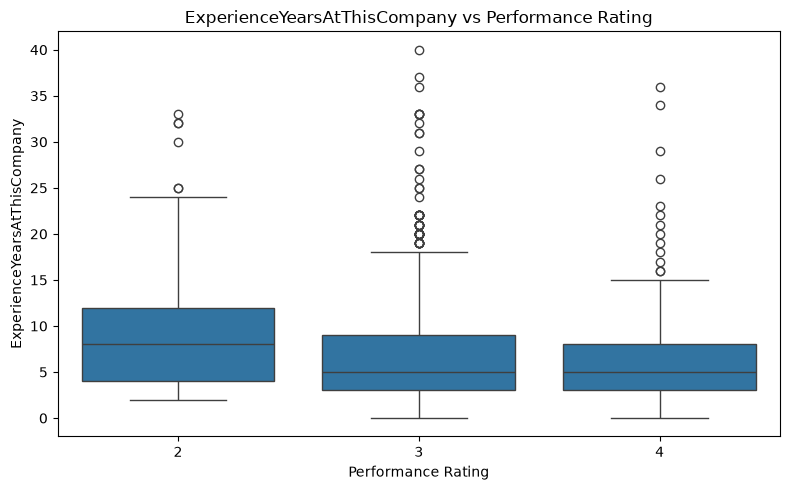

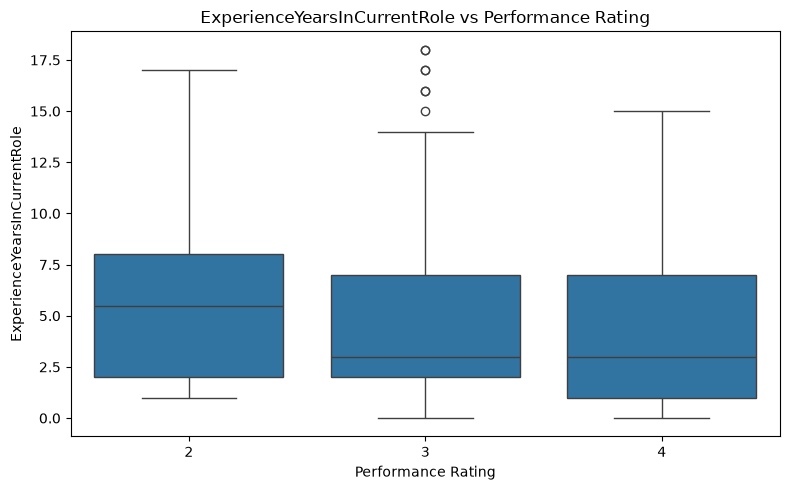

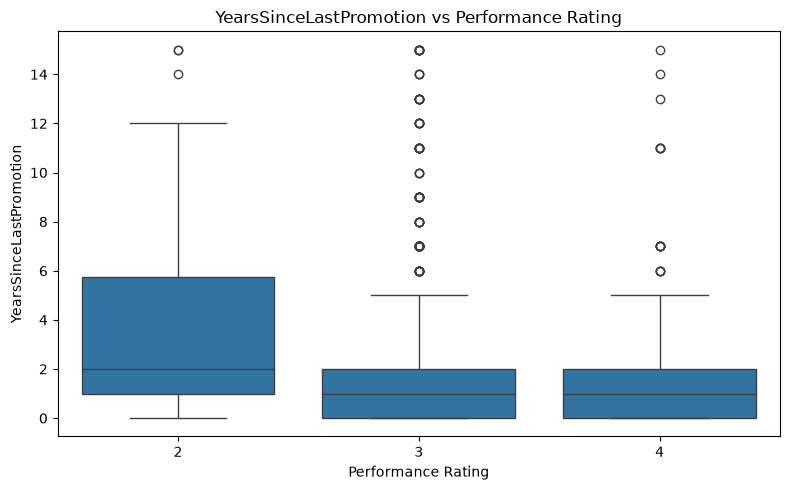

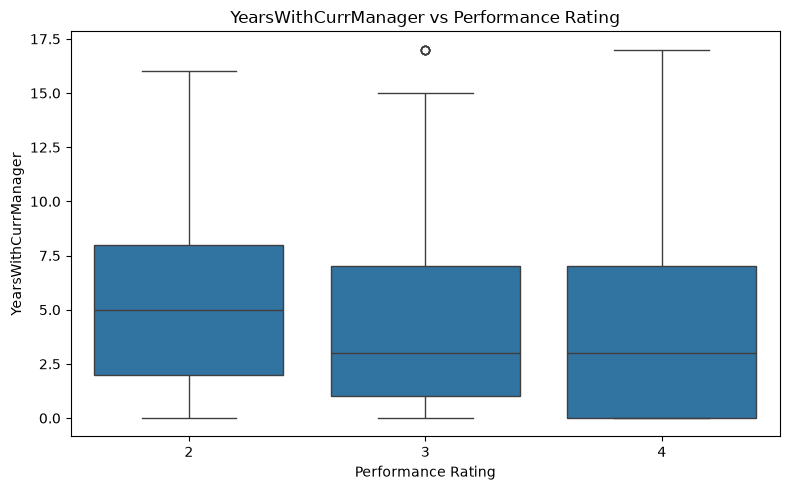

In [17]:
for column in numerical_columns:
    
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x="PerformanceRating",
        y=column,
        order=sorted(df["PerformanceRating"].unique())
    )
    
    plt.title(f"{column} vs Performance Rating")
    plt.xlabel("Performance Rating")
    plt.ylabel(column)
    
    plt.tight_layout()
    plt.show()

In [18]:
numerical_by_performance = (
    df.groupby("PerformanceRating")[numerical_columns]
    .mean()
    .T
    .round(2)
)

display(numerical_by_performance)

PerformanceRating,2,3,4
Age,37.80,36.78,36.50
DistanceFromHome,9.84,9.14,8.37
EmpHourlyRate,68.22,65.61,65.16
EmpJobLevel,2.30,2.02,2.02
NumCompaniesWorked,2.57,2.67,2.77
EmpLastSalaryHikePercent,15.07,14.43,20.70
TotalWorkExperienceInYears,12.75,11.08,10.92
TrainingTimesLastYear,2.76,2.80,2.71
ExperienceYearsAtThisCompany,9.10,6.68,6.77
ExperienceYearsInCurrentRole,5.79,4.01,3.98


### 1.8 Ordinal Variables vs Performance Rating

The ordinal variables are analyzed against `PerformanceRating` because their numerical values represent ordered levels.

The analysis examines whether employee performance-rating distributions vary across increasing levels of education, satisfaction, involvement, and work-life balance.

Because these variables have an inherent order, their patterns are examined using both group-level summaries and visualizations.

In [19]:
ordinal_columns = [
    "EmpEducationLevel",
    "EmpEnvironmentSatisfaction",
    "EmpJobInvolvement",
    "EmpJobSatisfaction",
    "EmpRelationshipSatisfaction",
    "EmpWorkLifeBalance"
]

print("Ordinal variables:")
for column in ordinal_columns:
    print("-", column)

Ordinal variables:
- EmpEducationLevel
- EmpEnvironmentSatisfaction
- EmpJobInvolvement
- EmpJobSatisfaction
- EmpRelationshipSatisfaction
- EmpWorkLifeBalance


In [20]:
for column in ordinal_columns:
    
    print("=" * 80)
    print(f"{column} vs PerformanceRating")
    print("=" * 80)
    
    percentage_table = pd.crosstab(
        df[column],
        df["PerformanceRating"],
        normalize="index"
    ).mul(100).round(2)
    
    display(percentage_table)

EmpEducationLevel vs PerformanceRating


PerformanceRating,2,3,4
EmpEducationLevel,,,
1,22.30,68.24,9.46
2,16.32,72.38,11.30
3,13.36,74.61,12.03
4,16.15,73.91,9.94
5,23.81,64.29,11.90


EmpEnvironmentSatisfaction vs PerformanceRating


PerformanceRating,2,3,4
EmpEnvironmentSatisfaction,,,
1,39.13,55.22,5.65
2,40.50,53.72,5.79
3,0.82,84.47,14.71
4,0.83,85.04,14.13


EmpJobInvolvement vs PerformanceRating


...

PerformanceRating,2,3,4
EmpJobSatisfaction,,,
1,16.45,70.13,13.42
2,12.66,79.32,8.02
3,19.21,71.75,9.04
4,15.34,71.43,13.23


EmpRelationshipSatisfaction vs PerformanceRating


PerformanceRating,2,3,4
EmpRelationshipSatisfaction,,,
1,17.35,70.32,12.33
2,15.38,73.68,10.93
3,14.51,73.88,11.61
4,17.75,72.68,9.58


EmpWorkLifeBalance vs PerformanceRating


PerformanceRating,2,3,4
EmpWorkLifeBalance,,,
1,25.00,75.00,0.00
2,17.35,73.47,9.18
3,15.82,73.31,10.87
4,10.43,66.96,22.61


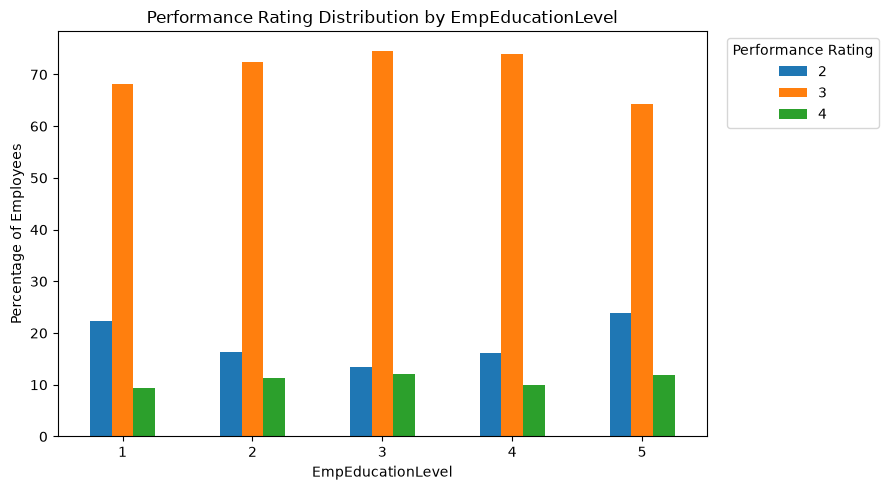

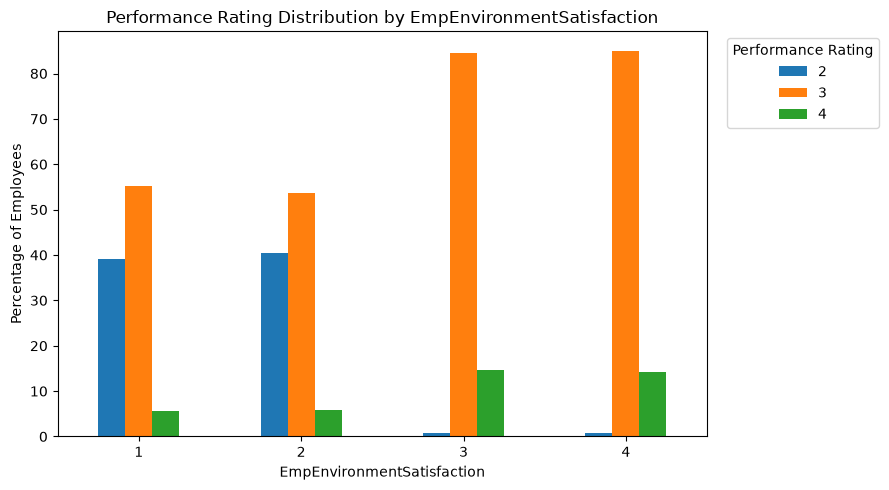

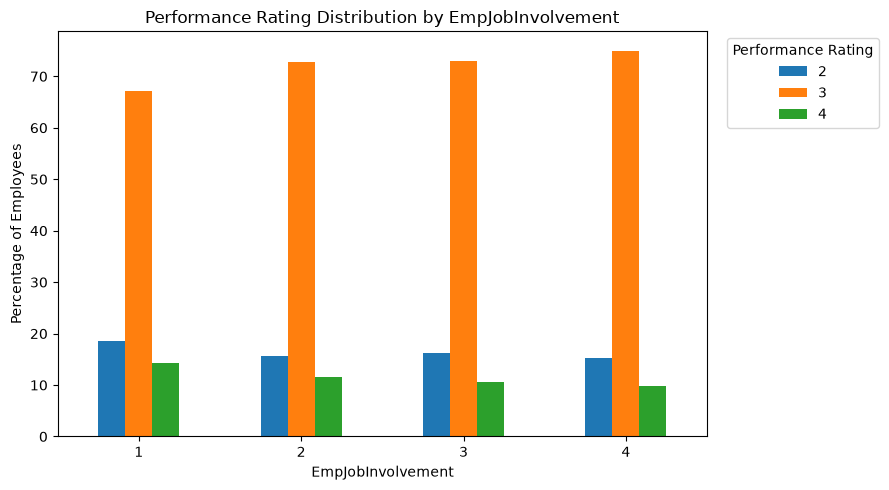

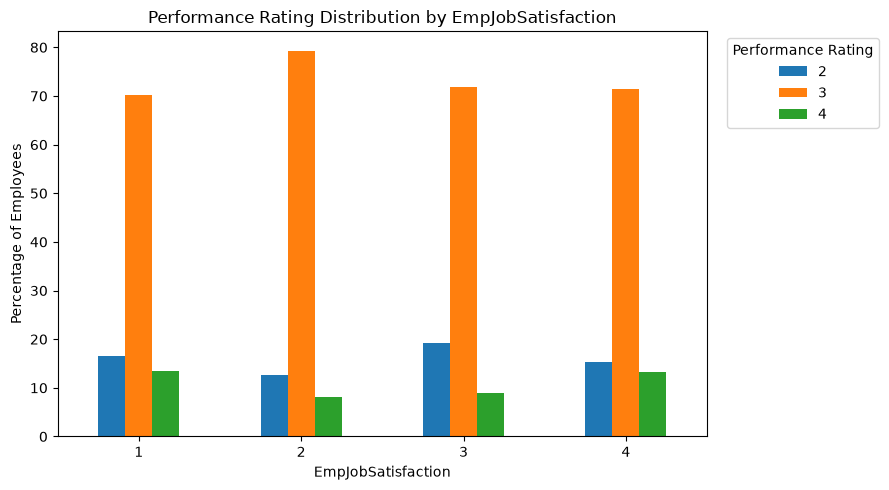

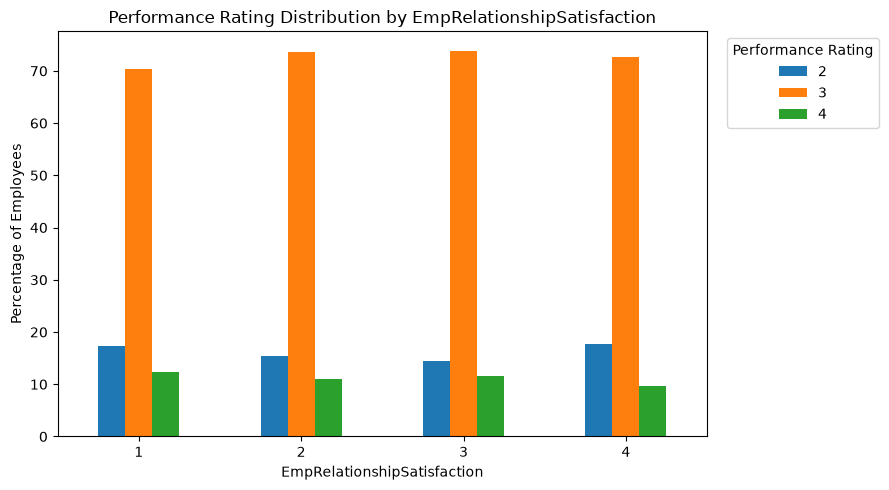

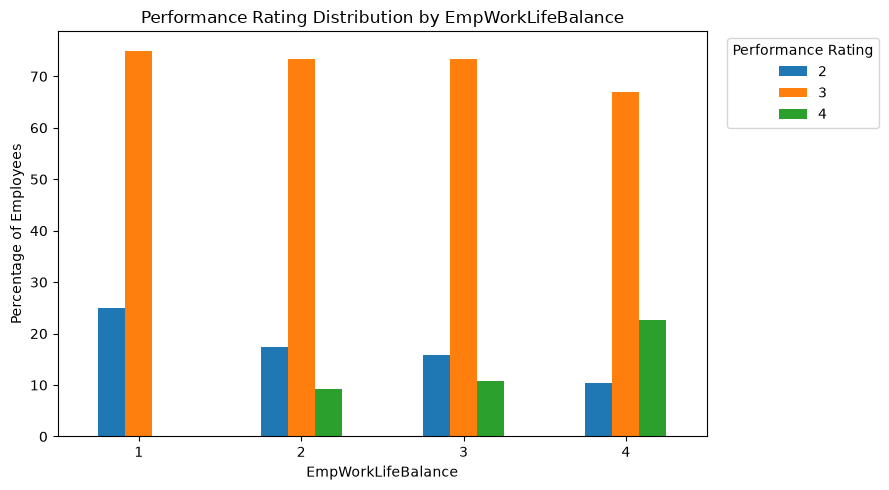

In [21]:
for column in ordinal_columns:
    
    percentage_table = pd.crosstab(
        df[column],
        df["PerformanceRating"],
        normalize="index"
    ).mul(100)
    
    percentage_table.plot(
        kind="bar",
        figsize=(9, 5)
    )
    
    plt.title(f"Performance Rating Distribution by {column}")
    plt.xlabel(column)
    plt.ylabel("Percentage of Employees")
    plt.xticks(rotation=0)
    
    plt.legend(
        title="Performance Rating",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    
    plt.tight_layout()
    plt.show()

### 1.9 Correlation Analysis

Correlation analysis is performed to examine the relationships between numerical and ordinal variables.

The analysis helps identify strongly related features and potential multicollinearity among employee experience and organizational variables.

Correlation with `PerformanceRating` is also examined as an initial measure of linear association.

Correlation does not imply causation, and classification-model performance and feature-importance analysis will be used later to evaluate predictive usefulness.

In [22]:
correlation_columns = numerical_columns + ordinal_columns

correlation_matrix = df[correlation_columns].corr()

display(correlation_matrix.round(2))

,Age,DistanceFromHome,EmpHourlyRate,EmpJobLevel,NumCompaniesWorked,EmpLastSalaryHikePercent,TotalWorkExperienceInYears,TrainingTimesLastYear,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpJobInvolvement,EmpJobSatisfaction,EmpRelationshipSatisfaction,EmpWorkLifeBalance
Age,1.00,0.02,0.06,0.51,0.28,-0.01,0.68,-0.02,0.32,0.22,0.23,0.21,0.21,0.01,0.03,-0.00,0.05,-0.02
DistanceFromHome,0.02,1.00,0.01,0.02,-0.02,0.04,0.03,-0.03,0.02,0.02,0.01,0.02,0.05,-0.02,0.00,-0.00,-0.01,-0.04
EmpHourlyRate,0.06,0.01,1.00,-0.02,0.04,-0.02,0.03,-0.02,-0.00,-0.01,-0.01,-0.00,0.01,-0.05,0.05,-0.07,0.01,0.02
EmpJobLevel,0.51,0.02,-0.02,1.00,0.13,-0.02,0.78,-0.00,0.54,0.40,0.36,0.37,0.10,-0.01,-0.03,-0.01,0.00,0.05
NumCompaniesWorked,0.28,-0.02,0.04,0.13,1.00,-0.01,0.22,-0.05,-0.13,-0.10,-0.03,-0.11,0.13,0.02,0.02,-0.05,0.06,0.00
EmpLastSalaryHikePercent,-0.01,0.04,-0.02,-0.02,-0.01,1.00,-0.01,-0.01,-0.02,-0.00,-0.02,-0.01,0.00,-0.05,-0.00,0.03,-0.04,-0.02
TotalWorkExperienceInYears,0.68,0.03,0.03,0.78,0.22,-0.01,1.00,-0.02,0.63,0.46,0.41,0.46,0.15,-0.01,-0.03,-0.03,0.02,0.02
TrainingTimesLastYear,-0.02,-0.03,-0.02,-0.00,-0.05,-0.01,-0.02,1.00,0.01,0.01,0.02,-0.01,-0.01,0.00,-0.03,-0.03,0.03,0.04
ExperienceYearsAtThisCompany,0.32,0.02,-0.00,0.54,-0.13,-0.02,0.63,0.01,1.00,0.76,0.62,0.76,0.08,-0.00,-0.04,0.00,0.02,0.02
ExperienceYearsInCurrentRole,0.22,0.02,-0.01,0.40,-0.10,-0.00,0.46,0.01,0.76,1.00,0.54,0.73,0.07,0.03,0.00,0.00,-0.03,0.05


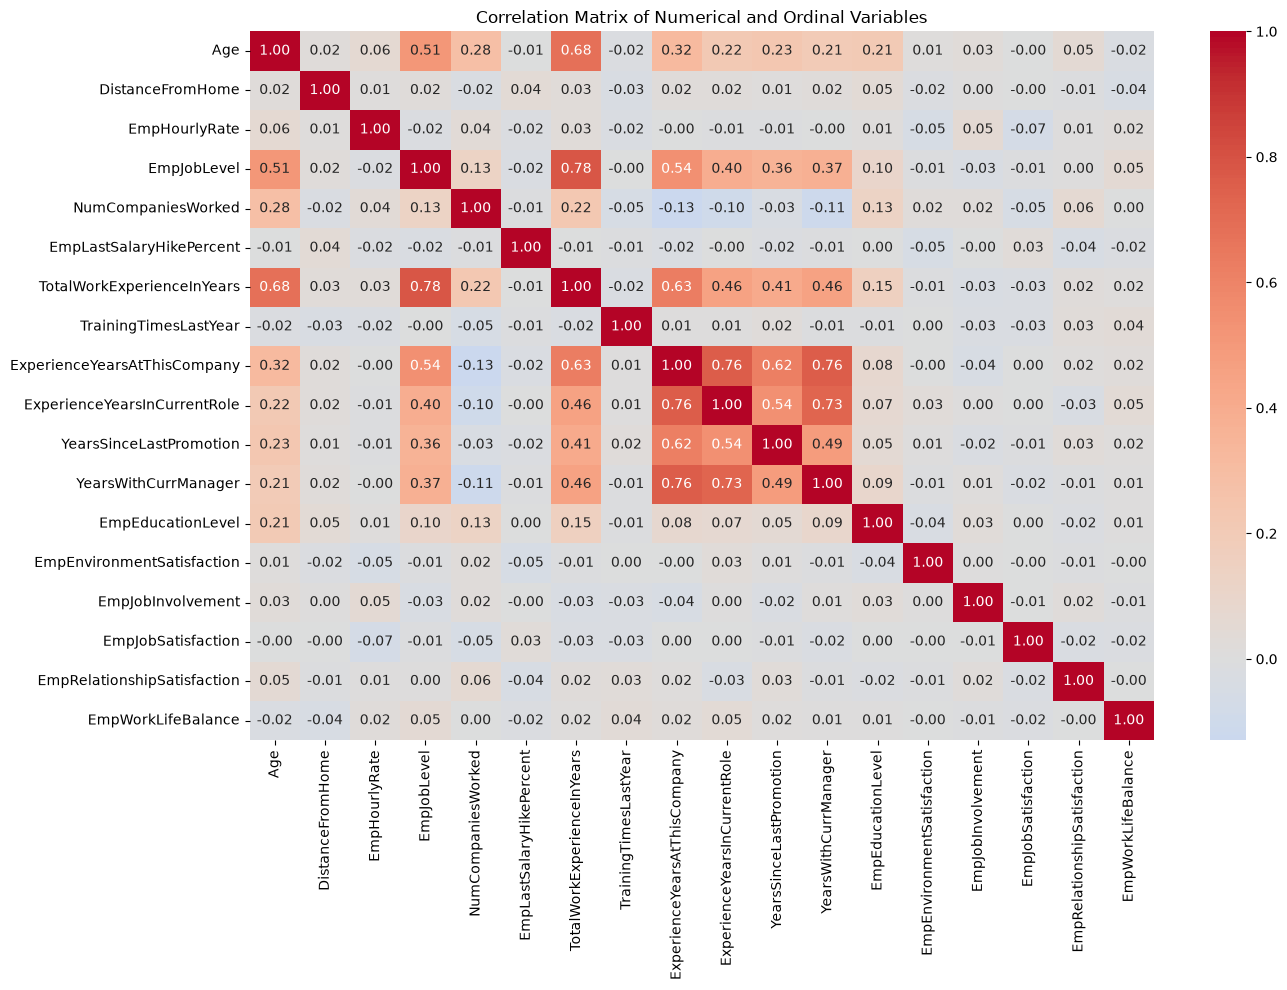

In [23]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical and Ordinal Variables")
plt.tight_layout()
plt.show()

In [24]:
target_correlations = (
    df[correlation_columns + ["PerformanceRating"]]
    .corr()["PerformanceRating"]
    .drop("PerformanceRating")
    .sort_values(key=abs, ascending=False)
    .round(3)
)

display(
    target_correlations.to_frame(
        name="Correlation with PerformanceRating"
    )
)

,Correlation with PerformanceRating
EmpEnvironmentSatisfaction,0.396
EmpLastSalaryHikePercent,0.334
YearsSinceLastPromotion,-0.168
ExperienceYearsInCurrentRole,-0.148
EmpWorkLifeBalance,0.124
YearsWithCurrManager,-0.122
ExperienceYearsAtThisCompany,-0.112
EmpJobLevel,-0.077
TotalWorkExperienceInYears,-0.068
DistanceFromHome,-0.046


### 1.10 Statistical Significance Testing

Statistical tests are performed to determine whether the observed differences between employee groups and performance-rating categories are statistically significant.

The Chi-square test of independence is used for categorical variables.

The Kruskal-Wallis test is used for numerical and ordinal variables across the three performance-rating groups.

A significance level of 0.05 is used as the threshold for statistical significance.

Statistical significance indicates evidence of an association in the observed data; it does not establish causation.

In [25]:
from scipy.stats import chi2_contingency, kruskal

alpha = 0.05

print(f"Significance level (alpha): {alpha}")

Significance level (alpha): 0.05


In [26]:
categorical_test_columns = [
    "Gender",
    "EducationBackground",
    "MaritalStatus",
    "EmpDepartment",
    "EmpJobRole",
    "BusinessTravelFrequency",
    "OverTime",
    "Attrition"
]

chi_square_results = []

for column in categorical_test_columns:
    
    contingency_table = pd.crosstab(
        df[column],
        df["PerformanceRating"]
    )
    
    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )
    
    chi_square_results.append({
        "Variable": column,
        "Chi2": chi2,
        "p_value": p_value,
        "Significant_at_0.05": p_value < alpha
    })

chi_square_results = pd.DataFrame(chi_square_results)

chi_square_results = chi_square_results.sort_values(
    "p_value"
)

display(chi_square_results.round(4))

,Variable,Chi2,p_value,Significant_at_0.05
3,EmpDepartment,70.3280,0.0000,True
4,EmpJobRole,97.7407,0.0000,True
6,OverTime,11.2825,0.0035,True
2,MaritalStatus,6.1333,0.1894,False
7,Attrition,2.5671,0.2771,False
5,BusinessTravelFrequency,4.3973,0.3549,False
1,EducationBackground,10.2174,0.4216,False
0,Gender,0.1630,0.9218,False


In [27]:
kruskal_results = []

for column in numerical_columns + ordinal_columns:
    
    groups = [
        df.loc[
            df["PerformanceRating"] == rating,
            column
        ]
        for rating in sorted(df["PerformanceRating"].unique())
    ]
    
    statistic, p_value = kruskal(*groups)
    
    kruskal_results.append({
        "Variable": column,
        "Kruskal_Wallis_H": statistic,
        "p_value": p_value,
        "Significant_at_0.05": p_value < alpha
    })

kruskal_results = pd.DataFrame(kruskal_results)

kruskal_results = kruskal_results.sort_values(
    "p_value"
)

display(kruskal_results.round(4))

,Variable,Kruskal_Wallis_H,p_value,Significant_at_0.05
13,EmpEnvironmentSatisfaction,247.3394,0.0000,True
5,EmpLastSalaryHikePercent,235.5897,0.0000,True
10,YearsSinceLastPromotion,124.9210,0.0000,True
9,ExperienceYearsInCurrentRole,46.8982,0.0000,True
11,YearsWithCurrManager,31.6296,0.0000,True
8,ExperienceYearsAtThisCompany,29.4305,0.0000,True
17,EmpWorkLifeBalance,18.7265,0.0001,True
3,EmpJobLevel,11.1663,0.0038,True
6,TotalWorkExperienceInYears,9.5322,0.0085,True
2,EmpHourlyRate,2.9929,0.2239,False


### 1.11 Department-wise Performance Analysis

Department-wise performance is analyzed to compare the distribution of employee performance ratings across departments.

Both employee counts and within-department percentages are considered because the departments have different numbers of employees.

The analysis is used to identify departments with relatively different performance-rating distributions and to support department-level business recommendations.

In [28]:
department_performance = pd.crosstab(
    df["EmpDepartment"],
    df["PerformanceRating"]
)

department_performance_percentage = (
    pd.crosstab(
        df["EmpDepartment"],
        df["PerformanceRating"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print("Department-wise Performance Counts")
display(department_performance)

print("\nDepartment-wise Performance Percentages")
display(department_performance_percentage)

Department-wise Performance Counts


PerformanceRating,2,3,4
EmpDepartment,,,
Data Science,1,17,2
Development,13,304,44
Finance,15,30,4
Human Resources,10,38,6
Research & Development,68,234,41
Sales,87,251,35



Department-wise Performance Percentages


PerformanceRating,2,3,4
EmpDepartment,,,
Data Science,5.00,85.00,10.00
Development,3.60,84.21,12.19
Finance,30.61,61.22,8.16
Human Resources,18.52,70.37,11.11
Research & Development,19.83,68.22,11.95
Sales,23.32,67.29,9.38


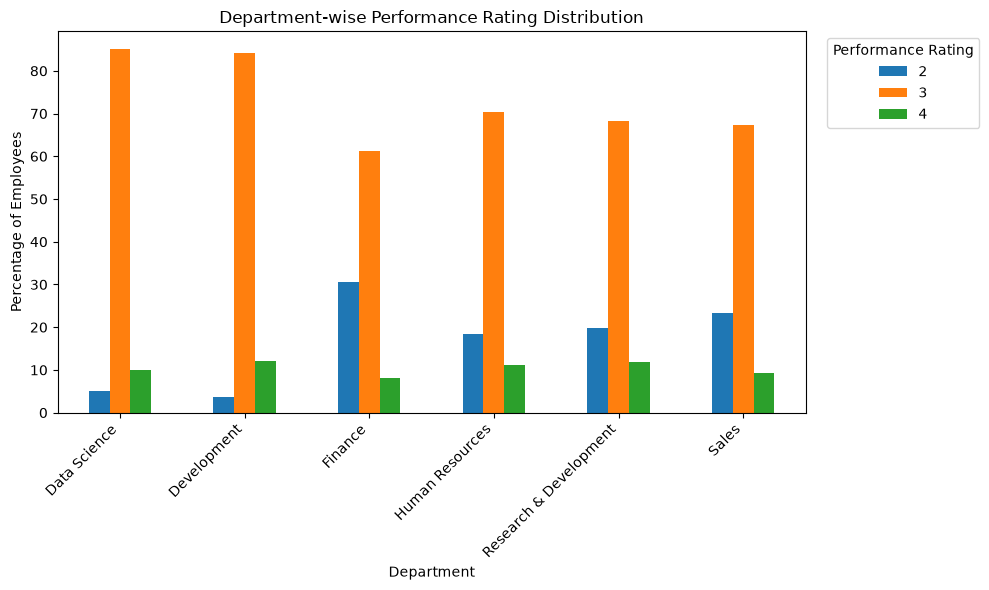

In [29]:
department_performance_percentage.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Department-wise Performance Rating Distribution")
plt.xlabel("Department")
plt.ylabel("Percentage of Employees")
plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Performance Rating",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### 1.12 Multivariate Relationship Analysis

The multivariate analysis examines selected variables that showed meaningful associations with `PerformanceRating` during the previous exploratory and statistical analyses.

The objective is to investigate whether combinations of employee characteristics and workplace factors reveal additional patterns that are not apparent from individual-variable analysis.

The analysis focuses on selected variables identified through exploratory analysis and statistical testing rather than generating visualizations for every possible feature combination.

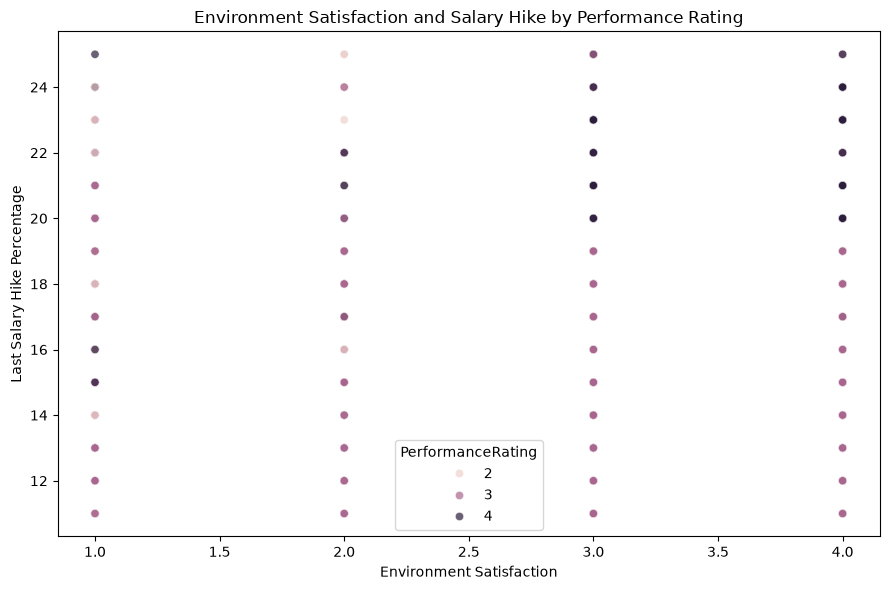

In [30]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="EmpEnvironmentSatisfaction",
    y="EmpLastSalaryHikePercent",
    hue="PerformanceRating",
    alpha=0.7
)

plt.title(
    "Environment Satisfaction and Salary Hike by Performance Rating"
)
plt.xlabel("Environment Satisfaction")
plt.ylabel("Last Salary Hike Percentage")

plt.tight_layout()
plt.show()

In [31]:
environment_salary_summary = (
    df.groupby(
        ["EmpEnvironmentSatisfaction", "PerformanceRating"]
    )["EmpLastSalaryHikePercent"]
    .agg(["count", "mean"])
    .round(2)
)

display(environment_salary_summary)

count   mean
EmpEnvironmentSatisfaction PerformanceRating              
1                          2                     90  15.00
                           3                    127  15.35
                           4                     13  20.69
2                          2                     98  15.15
                           3                    130  15.08
                           4                     14  18.00
3                          2                      3  17.00
                           3                    310  14.15
                           4                     54  21.20
4                          2                      3  12.67
                           3                    307  14.05
                           4                     51  20.92

### 1.13 Exploratory Analysis — Key Findings

The exploratory and statistical analyses produced several important findings:

1. `PerformanceRating` is imbalanced, with Rating 3 representing the majority of employees.

2. Department-wise performance distributions differ across departments. Finance has the highest proportion of Rating 2 employees, while Development has the highest proportion of Rating 4 employees.

3. `EmpJobRole`, `EmpDepartment`, and `OverTime` show statistically significant associations with `PerformanceRating` based on the Chi-square test.

4. `EmpEnvironmentSatisfaction` and `EmpLastSalaryHikePercent` show the strongest positive correlations with `PerformanceRating` among the numerical and ordinal variables analyzed.

5. Several experience-related variables, particularly `YearsSinceLastPromotion` and `ExperienceYearsInCurrentRole`, show negative associations with `PerformanceRating` and statistically significant differences across performance-rating groups.

6. `EmpWorkLifeBalance` also shows a statistically significant relationship with performance rating, although its correlation is weaker than that of environment satisfaction and salary-hike percentage.

7. Variables such as `Gender`, `EducationBackground`, `BusinessTravelFrequency`, `EmpJobSatisfaction`, `EmpJobInvolvement`, and `TrainingTimesLastYear` do not show statistically significant associations with `PerformanceRating` at the 0.05 significance level in the tests performed.

These findings are exploratory and describe associations in the observed employee data. Final feature importance will be evaluated using machine-learning models.

In [32]:
eda_summary = pd.DataFrame({
    "Area": [
        "Target distribution",
        "Categorical variables",
        "Strongest numerical/ordinal association",
        "Other significant numerical/ordinal variables",
        "Department analysis"
    ],
    "Key_Finding": [
        "Performance Rating 3 is the dominant class.",
        "EmpJobRole, EmpDepartment, and OverTime show significant associations.",
        "EmpEnvironmentSatisfaction and EmpLastSalaryHikePercent have the strongest correlations.",
        "Experience and promotion variables and EmpWorkLifeBalance show significant group differences.",
        "Performance distributions vary across departments."
    ]
})

display(eda_summary)

,Area,Key_Finding
0,Target distribution,Performance Rating 3 is the dominant class.
1,Categorical variables,"EmpJobRole, EmpDepartment, and OverTime show s..."
2,Strongest numerical/ordinal association,EmpEnvironmentSatisfaction and EmpLastSalaryHi...
3,Other significant numerical/ordinal variables,Experience and promotion variables and EmpWork...
4,Department analysis,Performance distributions vary across departme...
